# Linear Regression

## What it is

Linear regression is a technique for predicting the value of a variable based on one or more other variables, assuming a linear (straight-line) relationship between them.

Mathematically: y = w · X + b, where y is the output (prediction), X is the input, w is the weight, and b is the bias.

Geometrically, it is a line whose slope is w, and b is the point where the line intersects the Y-axis (the y-intercept).

## What we are going to do

1. Generate synthetic data for linear regression
2. Build Model for prediction & loss function to find error in the prediction
3. Train model for a Single parameter "w"
4. Train model for two parameter "w" & "b"

### Generate synthetic data

In [ ]:
import torch
import matplotlib.pyplot as plt

Data & linear function with slope of -5.

In [24]:
X = torch.arange(-5, 5, 0.1).view(-1, 1)
func = -5 * X

Add Gaussian noise to data to simulate real world data

In [25]:
Y = func + 0.4 * torch.randn(X.size())

Plat data with the linear function

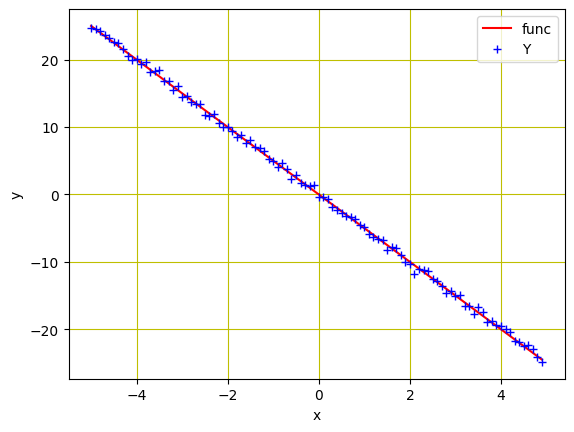

In [26]:
plt.plot(X.numpy(), func.numpy(), 'r', label="func")
plt.plot(X.numpy(), Y.numpy(), 'b+', label="Y")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid('True', color='y')
plt.show()

### Building Model & Loss function

Forward function of the model that will do prediction

In [27]:
def forward(x):
  return w * x

Loss function finds error in the prediction & actual output value. This help us to tell how we should tune weight of our model. Here we are calling it "criterion".

In [28]:
def criterion(y_pred, y):
  return torch.mean((y_pred - y) ** 2) # Mean square error

Now set "w" to a random variable with `requires_grad` to true. This is what we need to adjust for our model to make better predictions.

In [29]:
w = torch.tensor(-10.0, requires_grad=True)

Now we will define learning rate or step_size, iteration for how many times we will train our model and a list to store loss improvement with each iteration.

In [ ]:
learning_rate = 0.1
loss_list = []
iter = 21

Let's train our model

In [ ]:
for i in range(iter):
  Y_pred = forward(X)
  loss = criterion(Y_pred, Y)
  loss_list.append(loss.item())
  loss.backward()
  
  #Updating parameter of our model
  w.data = w.data - learning_rate * w.grad.data
  w.grad.data.zero_()
  print(f"{i}, \t{loss.item()}, \t{w.item()}")

0, 	209.18995666503906, 	-1.6522274017333984
1, 	93.16387939453125, 	-7.22019100189209
2, 	41.5451774597168, 	-3.506359577178955
3, 	18.580585479736328, 	-5.983485221862793
4, 	8.363897323608398, 	-4.331242084503174
5, 	3.818603754043579, 	-5.43328857421875
6, 	1.7964529991149902, 	-4.69822359085083
7, 	0.8968178033828735, 	-5.188511848449707
8, 	0.49658116698265076, 	-4.861489295959473
9, 	0.31852036714553833, 	-5.07961368560791
10, 	0.23930302262306213, 	-4.93412446975708
11, 	0.2040598839521408, 	-5.031166076660156
12, 	0.1883806437253952, 	-4.966439247131348
13, 	0.18140491843223572, 	-5.009612083435059
14, 	0.1783016324043274, 	-4.980815410614014
15, 	0.17692096531391144, 	-5.000022888183594
16, 	0.17630672454833984, 	-4.98721170425415
17, 	0.1760333776473999, 	-4.99575662612915
18, 	0.1759118139743805, 	-4.990056991577148
19, 	0.1758577525615692, 	-4.993858814239502
20, 	0.17583374679088593, 	-4.991322994232178


Notice above how weight "w" is approaching to "-5" as we used in our linear function that defines relation between input X & output Y.
And loss is approaching to zero

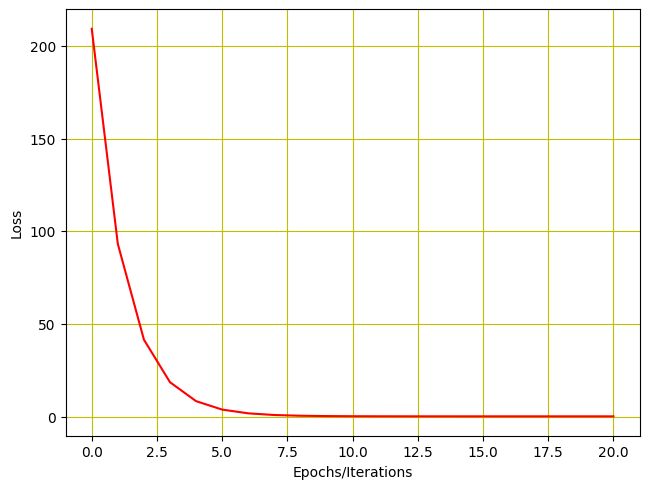

In [32]:
# Plotting the loss after each iteration
plt.plot(loss_list, 'r')
plt.tight_layout()
plt.grid('True', color='y')
plt.xlabel("Epochs/Iterations")
plt.ylabel("Loss")
plt.show()

Train model for two parameters, w & b.

Therefore we need to update the forward function of our model also.

In [33]:
def forward(x):
  return w * x + b

Set random values for both

In [34]:
w = torch.tensor(-10.0, requires_grad = True)
b = torch.tensor(-20.0, requires_grad = True)

In [ ]:
learning_rate = 0.1
loss_list = []
iter = 21

for i in range(iter):
  Y_pred = forward(X)
  loss = criterion(Y_pred, Y)
  loss_list.append(loss.item())

  loss.backward()
  
  w.data = w.data - learning_rate * w.grad.data
  b.data = b.data - learning_rate * b.grad.data

  w.grad.data.zero_()
  b.grad.data.zero_()

  print(f"{i}, \t{loss.item()}, \t{w.item()}, \t{b.item()}")

0, 	599.8472900390625, 	-1.8522272109985352, 	-16.04671287536621
1, 	345.43682861328125, 	-7.247257709503174, 	-12.802606582641602
2, 	204.00689697265625, 	-3.6163322925567627, 	-10.261271476745605
3, 	123.00794982910156, 	-6.0127458572387695, 	-8.19189453125
4, 	75.40121459960938, 	-4.393644332885742, 	-6.560357093811035
5, 	46.81502914428711, 	-5.457269668579102, 	-5.238935947418213
6, 	29.356576919555664, 	-4.734617233276367, 	-4.192435264587402
7, 	18.554973602294922, 	-5.2061614990234375, 	-3.348008155822754
8, 	11.807058334350586, 	-4.88319730758667, 	-2.6771817207336426
9, 	7.561649322509766, 	-5.0919060707092285, 	-2.1372909545898438
10, 	4.877053737640381, 	-4.947298526763916, 	-1.7074655294418335
11, 	3.173271894454956, 	-5.039453506469727, 	-1.3621591329574585
12, 	2.0891854763031006, 	-4.9745330810546875, 	-1.086835503578186
13, 	1.3981528282165527, 	-5.015081882476807, 	-0.8659273982048035
14, 	0.9571068286895752, 	-4.98582649230957, 	-0.6896064877510071
15, 	0.67536455392

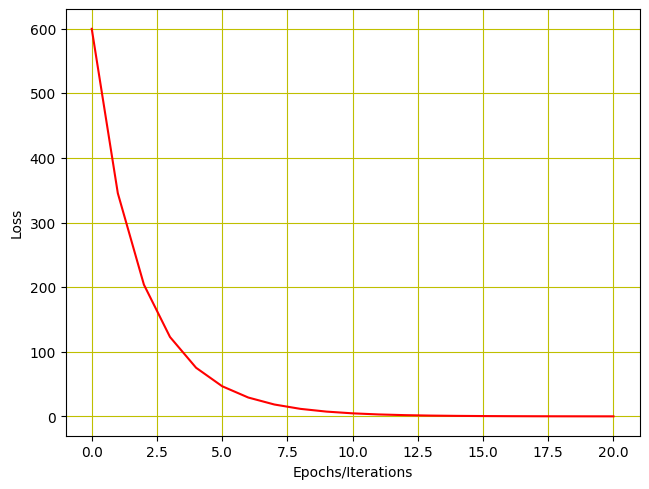

In [36]:
# Plotting the loss after each iteration
plt.plot(loss_list, 'r')
plt.tight_layout()
plt.grid('True', color='y')
plt.xlabel("Epochs/Iterations")
plt.ylabel("Loss")
plt.show()